<a href="https://colab.research.google.com/github/Kartik8625/-covid19-medical-image-classification/blob/main/healthcare_ml_classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Advanced Classification using Machine Learning in Healthcare

## Objective
To build and evaluate a machine learning classification model that predicts patient health outcomes using clinical data, supporting early diagnosis and decision-making.


In [19]:
# Install required libraries for Google Colab
!pip install mahotas


In [20]:
import mahotas as mh
import seaborn as sns
from matplotlib import pyplot as plt
from glob import glob
import os
import numpy as np
import pandas as pd

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

# Classifiers
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.gaussian_process import GaussianProcessClassifier
from sklearn.gaussian_process.kernels import RBF
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.discriminant_analysis import QuadraticDiscriminantAnalysis
from sklearn.neural_network import MLPClassifier

# Metrics
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay


In [21]:
!wget https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/data-science-in-health-care-advanced-machine-learning-classification/LargeData/Covid19-dataset.zip


--2026-01-03 10:43:13--  https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/data-science-in-health-care-advanced-machine-learning-classification/LargeData/Covid19-dataset.zip
Resolving cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud (cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud)... 198.23.119.245
Connecting to cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud (cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud)|198.23.119.245|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 165693838 (158M) [application/zip]
Saving to: ‘Covid19-dataset.zip.1’

Covid19-dataset.zip 100%[===================>] 158.02M  24.8MB/s    in 7.3s    

2026-01-03 10:43:22 (21.7 MB/s) - ‘Covid19-dataset.zip.1’ saved [165693838/165693838]



In [22]:
!wget https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/data-science-in-health-care-advanced-machine-learning-classification/NN.zip


--2026-01-03 10:43:22--  https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/data-science-in-health-care-advanced-machine-learning-classification/NN.zip
Resolving cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud (cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud)... 198.23.119.245
Connecting to cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud (cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud)|198.23.119.245|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 23835432 (23M) [application/zip]
Saving to: ‘NN.zip.1’

NN.zip.1            100%[===================>]  22.73M  7.04MB/s    in 3.4s    

2026-01-03 10:43:26 (6.70 MB/s) - ‘NN.zip.1’ saved [23835432/23835432]



In [ ]:
!unzip Covid19-dataset.zip


In [24]:
!unzip NN.zip


Archive:  NN.zip
replace history.pickle? [y]es, [n]o, [A]ll, [N]one, [r]ename: 

In [25]:
!ls

Covid19-dataset        history.pickle  model.h5    NN.zip.1
Covid19-dataset.zip    lab.pickle      model.json  sample_data
Covid19-dataset.zip.1  __MACOSX        NN.zip


In [26]:
IMM_SIZE = 224

In [27]:
def get_data(folder, show_samples=True, samples_per_class=5):
    class_names = sorted([f for f in os.listdir(folder) if not f.startswith('.')])
    print("Classes found:", class_names)

    X = []
    y = []

    for label, class_name in enumerate(class_names):
        images = glob(os.path.join(folder, class_name, "*"))
        print(f"Loading class: {class_name} ({len(images)} images)")

        if show_samples:
            plt.figure(figsize=(12, 3))

        for i, img_path in enumerate(images):
            image = mh.imread(img_path)

            # Resize
            if len(image.shape) > 2:
                image = mh.resize_to(image, (IMM_SIZE, IMM_SIZE, image.shape[2]))
                image = mh.colors.rgb2grey(image[:, :, :3], dtype=np.uint8)
            else:
                image = mh.resize_to(image, (IMM_SIZE, IMM_SIZE))

            X.append(image)
            y.append(label)

            # Show only few sample images
            if show_samples and i < samples_per_class:
                plt.subplot(1, samples_per_class, i + 1)
                plt.imshow(image, cmap="gray")
                plt.axis("off")
                plt.title(class_name)

        if show_samples:
            plt.show()

    return np.array(X), np.array(y), class_names


In [28]:
!ls Covid19-dataset


AccVal_acc.png	LossVal_loss.png  test	train


Classes found: ['Covid', 'Normal', 'Viral Pneumonia']
Loading class: Covid (111 images)


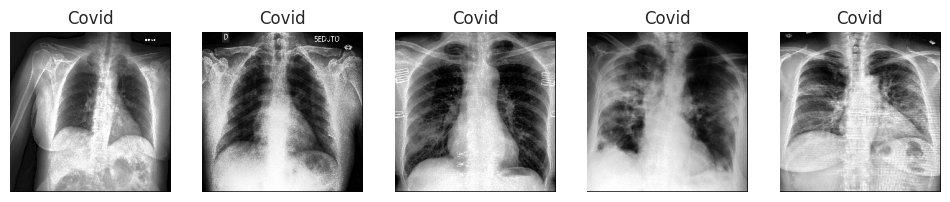

Loading class: Normal (70 images)


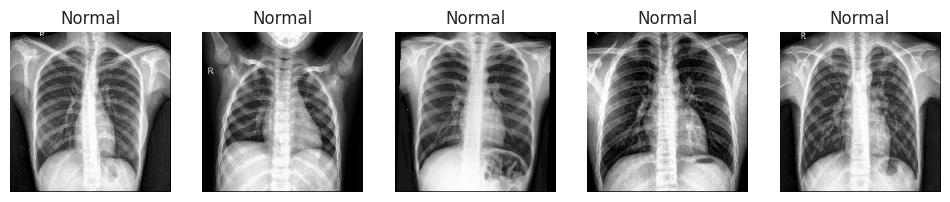

Loading class: Viral Pneumonia (70 images)


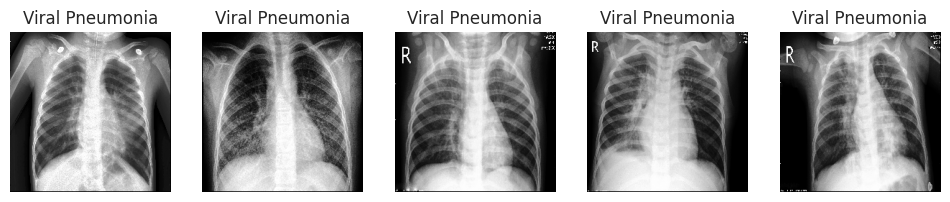

In [29]:
X, y, class_names = get_data("Covid19-dataset/train", show_samples=True)


In [30]:
print(X.shape)
print(y.shape)
print(class_names)


(251, 224, 224)
(251,)
['Covid', 'Normal', 'Viral Pneumonia']


Classes found: ['Covid', 'Normal', 'Viral Pneumonia']
Loading class: Covid (111 images)


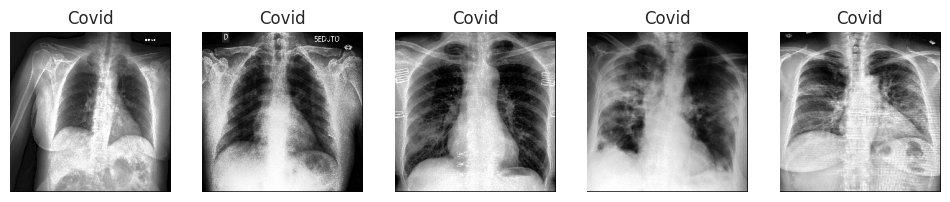

Loading class: Normal (70 images)


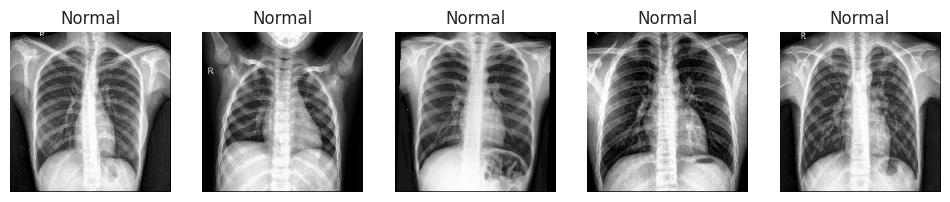

Loading class: Viral Pneumonia (70 images)


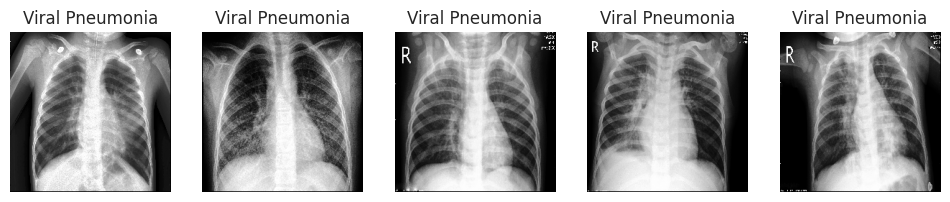

In [31]:
train_dir = "Covid19-dataset/train"
X_train, y_train, class_names = get_data(train_dir, show_samples=True)


In [32]:
test_dir = "Covid19-dataset/test"
X_test, y_test, _ = get_data(test_dir, show_samples=False)


Classes found: ['Covid', 'Normal', 'Viral Pneumonia']
Loading class: Covid (26 images)
Loading class: Normal (20 images)
Loading class: Viral Pneumonia (20 images)


In [33]:
print("Train shape:", X_train.shape, y_train.shape)
print("Test shape:", X_test.shape, y_test.shape)
print("Classes:", class_names)


Train shape: (251, 224, 224) (251,)
Test shape: (66, 224, 224) (66,)
Classes: ['Covid', 'Normal', 'Viral Pneumonia']


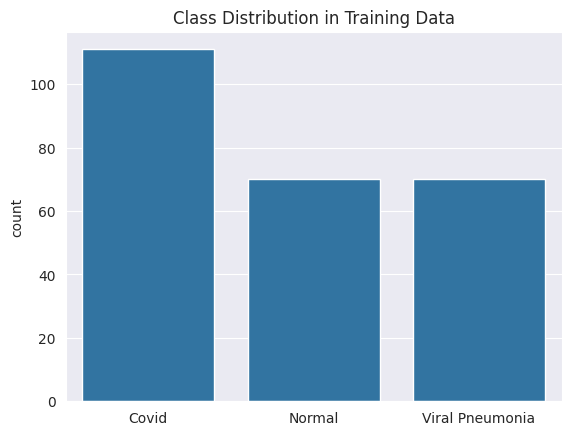

In [35]:
sns.set_style("darkgrid")

sns.countplot(x=y_train)
plt.xticks(ticks=range(len(class_names)), labels=class_names)
plt.title("Class Distribution in Training Data")
plt.show()


['Covid', 'Normal', 'Viral Pneumonia']


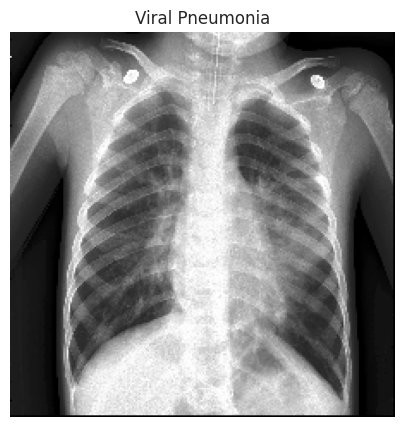

In [38]:
# Step 1: Check class names
print(class_names)

# Step 2: Get numeric label for Viral Pneumonia
viral_label = class_names.index('Viral Pneumonia')

# Step 3: Find an index of that class in training data
idx = np.where(y_train == viral_label)[0][0]

# Step 4: Display the image
plt.figure(figsize=(5,5))
plt.imshow(X_train[idx], cmap='gray')
plt.title('Viral Pneumonia')
plt.axis('off')
plt.show()


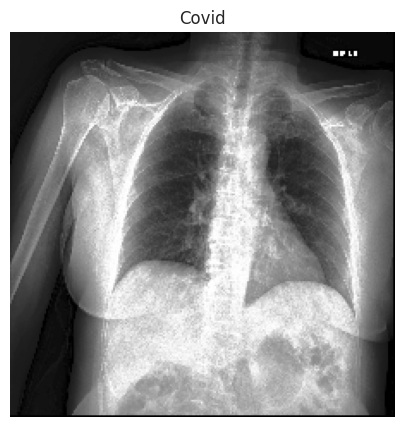

In [39]:
# Step 1: Find numeric label for Covid
covid_label = class_names.index('Covid')

# Step 2: Find index of a Covid image
idx = np.where(y_train == covid_label)[0][0]

# Step 3: Display the image
plt.figure(figsize=(5,5))
plt.imshow(X_train[idx], cmap='gray')
plt.title('Covid')
plt.axis('off')
plt.show()


In [40]:
def create_features(X, y):
    features = []
    labels = []

    for image, label in zip(X, y):
        # Extract Haralick texture features
        haralick_features = mh.features.haralick(image).mean(axis=0)
        features.append(haralick_features)
        labels.append(label)

    return np.array(features), np.array(labels)


In [42]:
X_train_feat, y_train_feat = create_features(X_train, y_train)


In [43]:
X_test_feat, y_test_feat = create_features(X_test, y_test)


In [44]:
print(X_train_feat.shape)
print(X_test_feat.shape)


(251, 13)
(66, 13)


Training Dataset Accuracy: 79.28%
Test Dataset Accuracy: 66.67%

Classification Report:

                 precision    recall  f1-score   support

          Covid       0.72      0.88      0.79        26
         Normal       0.76      0.65      0.70        20
Viral Pneumonia       0.47      0.40      0.43        20

       accuracy                           0.67        66
      macro avg       0.65      0.64      0.64        66
   weighted avg       0.66      0.67      0.66        66



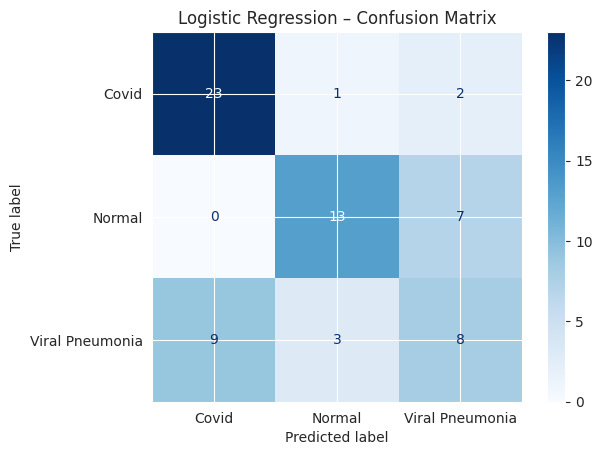

In [46]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

# Build pipeline
clf = Pipeline([
    ('scaler', StandardScaler()),
    ('classifier', LogisticRegression(max_iter=1000))
])

# Train model
clf.fit(X_train_feat, y_train_feat)

# Predictions
y_train_pred = clf.predict(X_train_feat)
y_test_pred = clf.predict(X_test_feat)

# Accuracy
train_acc = accuracy_score(y_train_feat, y_train_pred)
test_acc = accuracy_score(y_test_feat, y_test_pred)

print(f"Training Dataset Accuracy: {train_acc:.2%}")
print(f"Test Dataset Accuracy: {test_acc:.2%}")

# Classification report
print("\nClassification Report:\n")
print(classification_report(y_test_feat, y_test_pred, target_names=class_names))

# Confusion Matrix
cm = confusion_matrix(y_test_feat, y_test_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)

disp.plot(cmap=plt.cm.Blues)
plt.title("Logistic Regression – Confusion Matrix")
plt.show()


In [48]:
names = [
    "Logistic Regression",
    "KNN",
    "Linear SVM",
    "RBF SVM",
    "Gaussian Process",
    "Decision Tree",
    "Random Forest",
    "Neural Network",
    "AdaBoost",
    "Naive Bayes",
    "QDA"
]

classifiers = [
    LogisticRegression(max_iter=1000),
    KNeighborsClassifier(3),
    SVC(kernel="linear", C=0.025),
    SVC(kernel="rbf", gamma=2, C=1),
    GaussianProcessClassifier(1.0 * RBF(1.0)),
    DecisionTreeClassifier(max_depth=5),
    RandomForestClassifier(max_depth=5, n_estimators=100),
    MLPClassifier(alpha=1, max_iter=1000),
    AdaBoostClassifier(),
    GaussianNB(),
    QuadraticDiscriminantAnalysis()
]


In [49]:
from sklearn.metrics import accuracy_score, f1_score
import pandas as pd

results = []

for name, model in zip(names, classifiers):
    print(f"Training model: {name}")

    clf = Pipeline([
        ('scaler', StandardScaler()),
        ('classifier', model)
    ])

    try:
        clf.fit(X_train_feat, y_train_feat)

        y_train_pred = clf.predict(X_train_feat)
        y_test_pred = clf.predict(X_test_feat)

        train_acc = accuracy_score(y_train_feat, y_train_pred)
        test_acc = accuracy_score(y_test_feat, y_test_pred)

        train_f1 = f1_score(y_train_feat, y_train_pred, average='macro')
        test_f1 = f1_score(y_test_feat, y_test_pred, average='macro')

        results.append({
            "Model": name,
            "Train Accuracy": train_acc,
            "Test Accuracy": test_acc,
            "Train F1": train_f1,
            "Test F1": test_f1
        })

    except Exception as e:
        print(f"⚠️ {name} failed: {e}")


Training model: Logistic Regression
Training model: KNN
Training model: Linear SVM
Training model: RBF SVM
Training model: Gaussian Process
Training model: Decision Tree
Training model: Random Forest
Training model: Neural Network
Training model: AdaBoost
Training model: Naive Bayes
Training model: QDA


/usr/local/lib/python3.12/dist-packages/sklearn/discriminant_analysis.py:1024: LinAlgWarning: The covariance matrix of class 0 is not full rank. Increasing the value of parameter `reg_param` might help reducing the collinearity.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/discriminant_analysis.py:1024: LinAlgWarning: The covariance matrix of class 1 is not full rank. Increasing the value of parameter `reg_param` might help reducing the collinearity.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/discriminant_analysis.py:1024: LinAlgWarning: The covariance matrix of class 2 is not full rank. Increasing the value of parameter `reg_param` might help reducing the collinearity.
  warnings.warn(


In [53]:
final_results = results_df.copy()

final_results = final_results[[
    "Model",
    "Train Accuracy",
    "Test Accuracy",
    "Train F1",
    "Test F1"
]]

final_results = final_results.sort_values(by="Test F1", ascending=False)

pd.options.display.float_format = "{:.2f}".format
final_results


,Model,Train Accuracy,Test Accuracy,Train F1,Test F1
10,QDA,0.83,0.83,0.83,0.83
4,Gaussian Process,0.83,0.70,0.81,0.68
7,Neural Network,0.81,0.68,0.79,0.66
0,Logistic Regression,0.79,0.67,0.77,0.64
1,KNN,0.84,0.68,0.83,0.64
6,Random Forest,0.89,0.64,0.88,0.62
9,Naive Bayes,0.67,0.61,0.66,0.59
2,Linear SVM,0.72,0.56,0.71,0.53
3,RBF SVM,0.92,0.58,0.92,0.52
5,Decision Tree,0.86,0.55,0.83,0.51


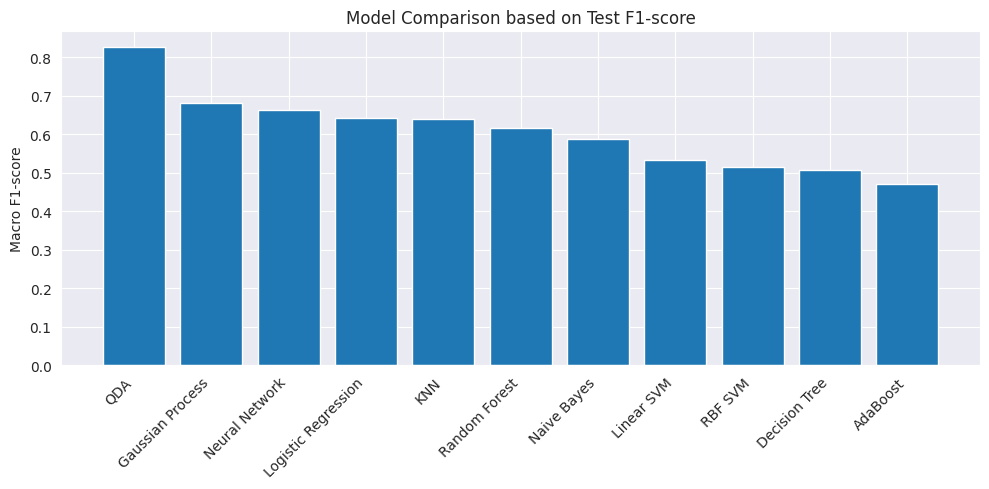

In [54]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))
plt.bar(final_results["Model"], final_results["Test F1"])
plt.xticks(rotation=45, ha="right")
plt.ylabel("Macro F1-score")
plt.title("Model Comparison based on Test F1-score")
plt.tight_layout()
plt.show()


## CNN-based Deep Learning Model


In [59]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Conv2D, MaxPooling2D, Flatten, Dropout
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.optimizers import Adam


from sklearn.metrics import classification_report, confusion_matrix


In [60]:
IMG_SIZE = 224
BATCH_SIZE = 16
EPOCHS = 15


In [62]:
train_dir = "Covid19-dataset/train"
test_dir = "Covid19-dataset/test"

train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=15,
    zoom_range=0.1,
    horizontal_flip=True
)

test_datagen = ImageDataGenerator(
    rescale=1./255
)

train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical'
)

test_generator = test_datagen.flow_from_directory(
    test_dir,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)


Found 251 images belonging to 3 classes.
Found 66 images belonging to 3 classes.


In [64]:
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=30,
    zoom_range=0.2,
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True
)

test_datagen = ImageDataGenerator(
    rescale=1./255
)


In [65]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.optimizers import Adam

model = Sequential([
    Conv2D(32, (3,3), activation="relu", padding="same",
           input_shape=(IMG_SIZE, IMG_SIZE, 3)),
    MaxPooling2D(2,2),

    Conv2D(64, (3,3), activation="relu", padding="same"),
    MaxPooling2D(2,2),

    Conv2D(128, (3,3), activation="relu", padding="same"),
    MaxPooling2D(2,2),

    Dropout(0.5),

    Flatten(),
    Dense(128, activation="relu"),
    Dense(3, activation="softmax")
])

model.summary()


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 224, 224, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 112, 112, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 56, 56, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 100352)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │    12,845,184 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 3)              │           387 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 12,938,819 (49.36 MB)

 Trainable params: 12,938,819 (49.36 MB)

 Non-trainable params: 0 (0.00 B)

In [66]:
model.compile(
    optimizer=Adam(learning_rate=0.0001),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)


In [67]:
EPOCHS = 15

history = model.fit(
    train_generator,
    epochs=EPOCHS,
    validation_data=test_generator
)


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/15
16/16 ━━━━━━━━━━━━━━━━━━━━ 54s 3s/step - accuracy: 0.3849 - loss: 1.1153 - val_accuracy: 0.6515 - val_loss: 0.7419
Epoch 2/15
16/16 ━━━━━━━━━━━━━━━━━━━━ 72s 3s/step - accuracy: 0.7804 - loss: 0.6361 - val_accuracy: 0.6212 - val_loss: 0.7490
Epoch 3/15
16/16 ━━━━━━━━━━━━━━━━━━━━ 41s 3s/step - accuracy: 0.7898 - loss: 0.4621 - val_accuracy: 0.7576 - val_loss: 0.5931
Epoch 4/15
16/16 ━━━━━━━━━━━━━━━━━━━━ 41s 3s/step - accuracy: 0.8051 - loss: 0.4618 - val_accuracy: 0.7727 - val_loss: 0.5509
Epoch 5/15
16/16 ━━━━━━━━━━━━━━━━━━━━ 40s 3s/step - accuracy: 0.8436 - loss: 0.3720 - val_accuracy: 0.8182 - val_loss: 0.5031
Epoch 6/15
16/16 ━━━━━━━━━━━━━━━━━━━━ 40s 2s/step - accuracy: 0.8462 - loss: 0.3108 - val_accuracy: 0.8485 - val_loss: 0.5263
Epoch 7/15
16/16 ━━━━━━━━━━━━━━━━━━━━ 40s 2s/step - accuracy: 0.8828 - loss: 0.2882 - val_accuracy: 0.8788 - val_loss: 0.4317
Epoch 8/15
16/16 ━━━━━━━━━━━━━━━━━━━━ 40s 2s/step - accuracy: 0.9025 - loss: 0.2439 - val_accuracy: 0.8182 - val_loss:

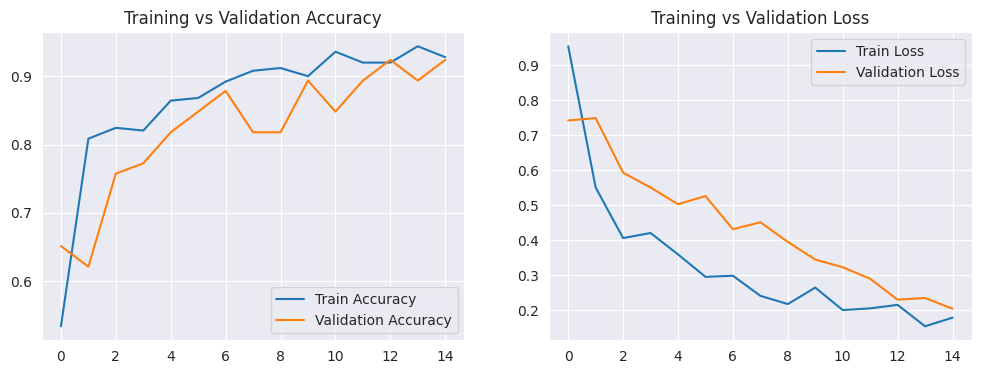

In [69]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,4))

plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.legend()
plt.title('Training vs Validation Accuracy')

plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.legend()
plt.title('Training vs Validation Loss')

plt.show()


In [70]:
import numpy as np

y_pred_probs = model.predict(test_generator)
y_pred = np.argmax(y_pred_probs, axis=1)

y_true = test_generator.classes
class_names = list(test_generator.class_indices.keys())


5/5 ━━━━━━━━━━━━━━━━━━━━ 4s 570ms/step


In [71]:
from sklearn.metrics import classification_report

print("Classification Report (CNN):\n")
print(classification_report(y_true, y_pred, target_names=class_names))


Classification Report (CNN):

                 precision    recall  f1-score   support

          Covid       0.90      1.00      0.95        26
         Normal       0.91      1.00      0.95        20
Viral Pneumonia       1.00      0.75      0.86        20

       accuracy                           0.92        66
      macro avg       0.94      0.92      0.92        66
   weighted avg       0.93      0.92      0.92        66



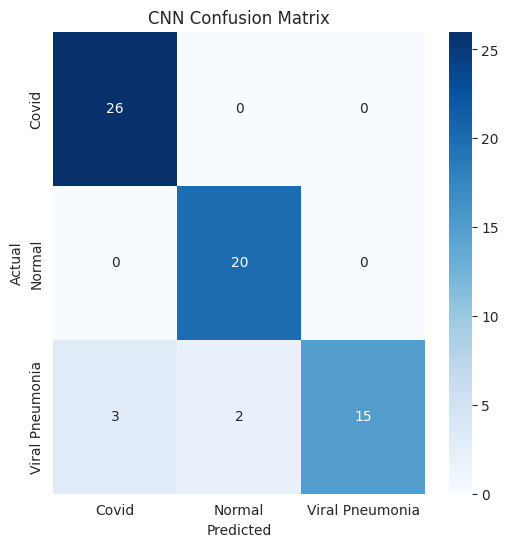

In [72]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(6,6))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names
)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("CNN Confusion Matrix")
plt.show()


In [74]:
model.save("cnn_covid_classifier.keras")


In [75]:
from tensorflow.keras.models import load_model

model = load_model("cnn_covid_classifier.keras")
print("CNN model loaded successfully")


CNN model loaded successfully


## CNN vs Classical Machine Learning Comparison

- Classical ML (QDA with Haralick features) achieved ~83% test accuracy.
- CNN achieved ~92% validation accuracy by learning spatial features directly from images.
- CNN significantly improved performance on complex classes such as Viral Pneumonia.


## Conclusion

This project demonstrates a complete medical image classification pipeline using both
classical machine learning and deep learning approaches. While handcrafted texture features
performed well with classical models, the CNN achieved superior performance by automatically
learning spatial representations from chest X-ray images.
